# Step 2c — Regression Analysis: Structural Relationships in Brazil's State-Level Trade

**Objective:** Test whether the structural indicators identified in Step 2b — product concentration (HHI), export frequency and shipment value density (USD/kg) — are systematically related across Brazilian states and stable over time.

**Relationship to Step 2b:** Step 2b introduces both regressions and presents the baseline results in the context of the broader state competitiveness analysis. This notebook extends that work — testing robustness across multiple specifications, quantifying the impact of Rio de Janeiro as a structural outlier, documenting the COVID-19 structural break and the post-2015 weakening trend, and synthesising both regressions into a unified state classification framework. The baseline results in Step 2b remain the entry point; the findings here are the deeper investigation.

**Prerequisites:** This notebook re-queries all required data independently from the database and does not depend on Step 2b dataframes being present in memory. Step 2b should be reviewed first as it provides the analytical context for the indicators used here.

---

This notebook covers:
1. Regression 1 - Export Frequency vs HHI (2c.1)
2. Regression 2 - Shipment Size vs Export Value Density (2c.2)
3. Synthesis - Comparing both regressions and their implications for state classification (2c.3)
4. Key Findings (2c.4)

Both regressions are run across five specifications to test robustness:

| Specification | Description |
|---|---|
| v1 | All years, non-geographic entries excluded at SQL level — primary reported result |
| v2 | Non-geographic excluded, COVID years (2020–2023) excluded |
| v3 | Non-geographic excluded, Rio de Janeiro excluded |
| v4 | Non-geographic excluded, Rio de Janeiro excluded, COVID years excluded — preferred structural estimate |

## Setup

This section establishes the analytical framework by defining temporal exclusions (COVID period), applying geographic filters, and standardizing regional classifications.  
It also constructs a consistent state-level dataset and visualization scheme to ensure comparability across all subsequent analyses.

In [46]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from pathlib import Path
from dotenv import load_dotenv
import os
from sqlalchemy import create_engine

# Credentials
dotenv_path = Path(r"C:\Users\e_koh\Downloads\State Analysis\brazil-state-trade-analysis\.env")
load_dotenv(dotenv_path, override=True)

DB_USER     = os.getenv('DB_USER')
DB_PASSWORD = os.getenv('DB_PASSWORD')
DB_HOST     = os.getenv('DB_HOST', 'localhost')
DB_PORT     = os.getenv('DB_PORT', '5432')
DB_NAME     = os.getenv('DB_NAME')

engine = create_engine(
    f'postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
)

MAX_YEAR     = 2025
COVID_EXCLUDE = [2020, 2021, 2022, 2023]

## Region name translation applied throughout
region_name_map = {
    'REGIAO NORDESTE'    : 'Northeast',
    'REGIAO NORTE'       : 'North',
    'REGIAO SUDESTE'     : 'Southeast',
    'REGIAO CENTRO OESTE': 'Center-West',
    'REGIAO SUL'         : 'South',
}

## Non-geographic region filter applied at SQL level in all queries
GEO_FILTER = """
    AND u.nome_regiao NOT IN (
        'REGIAO NAO DECLARADA',
        'CONSUMO DE BORDO',
        'MERCADORIA NACIONALIZADA',
        'REEXPORTACAO'
    )
"""

## Load state reference table
df_state = pd.read_sql(
    f"""
    SELECT u.sigla AS uf,
           u.nome_estado AS state,
           u.nome_regiao AS region,
           COALESCE(e.exports_usd, 0) / 1e9 AS exports_usd_bn
    FROM uf u
    LEFT JOIN (
        SELECT \"SG_UF_NCM\", SUM(\"VL_FOB\") AS exports_usd
        FROM exp WHERE \"CO_ANO\" = {MAX_YEAR}
        GROUP BY \"SG_UF_NCM\"
    ) e ON u.sigla = e.\"SG_UF_NCM\"
    WHERE u.nome_regiao NOT IN (
        'REGIAO NAO DECLARADA','CONSUMO DE BORDO',
        'MERCADORIA NACIONALIZADA','REEXPORTACAO'
    )
    ORDER BY exports_usd_bn DESC
    """,
    engine
)
df_state = df_state[~df_state['state'].isin(['Nao Declarada', 'Exterior'])]
df_state['region'] = df_state['region'].map(region_name_map).fillna(df_state['region'])

## Standard region colour palette used across all charts
REGION_COLORS = {
    'Northeast'  : 'steelblue',
    'North'      : 'tomato',
    'Southeast'  : 'seagreen',
    'Center-West': 'darkorange',
    'South'      : 'mediumpurple',
}

print(f'Setup complete. MAX_YEAR={MAX_YEAR}. States loaded: {len(df_state)}')

Setup complete. MAX_YEAR=2025. States loaded: 27


## 2c.1 - Regression 1: Export Frequency vs HHI

Testing whether a state's product concentration (HHI) predicts its export transaction frequency -- the hypothesis being that states concentrated in a few bulk commodities transact less frequently than diversified industrial states.

The relationship is examined through a pooled panel regression covering 1997-2025 with year-by-year results to test whether the relationship is stable over time. A single-year regression is presented for context but is insufficient on its own given the small cross-section of 27 states.

Non-geographic entries (CONSUMO DE BORDO, MERCADORIA NACIONALIZADA, REEXPORTACAO) are excluded from the preferred specification at the SQL level. COVID-19 (2020-2023) represents a structural break. Rio de Janeiro is flagged as a structural outlier driven by oil port processing volumes rather than product diversification.

***Note**: shipment count is derived from row count in the `exp` table rather than an official transaction register -- liquid bulk commodities such as oil may generate records at a different granularity than containerised or solid bulk goods, which partly explains Rio de Janeiro's anomalously high frequency.*

### 2c.1.1 - All Specifications: Regression 1

Regression 1 examines whether states that export more frequently — measured as the number of individual shipments — tend to export a more diversified product range, measured by HHI. A negative slope confirms the relationship: higher shipment frequency is associated with lower product concentration. The regression is estimated in log scale for frequency (log_freq) against raw HHI, pooled across all states and years, then re-estimated year by year to test whether the relationship is stable over time.

In [47]:
## Frequency query -- non-geographic excluded at SQL level
query_freq = f"""
    SELECT e."CO_ANO" AS year,
           e."SG_UF_NCM" AS uf,
           u.nome_estado AS state,
           COUNT(*) AS shipment_count,
           SUM(e."VL_FOB") AS exports_usd,
           SUM(e."KG_LIQUIDO") AS total_kg
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    WHERE e."CO_ANO" <= {MAX_YEAR}
    AND u.nome_regiao NOT IN (
        'REGIAO NAO DECLARADA','CONSUMO DE BORDO',
        'MERCADORIA NACIONALIZADA','REEXPORTACAO'
    )
    GROUP BY e."CO_ANO", e."SG_UF_NCM", u.nome_estado
    ORDER BY year, shipment_count DESC
"""

## HHI query -- non-geographic excluded at SQL level
query_hhi = f"""
    SELECT year, uf,
           SUM(sector_exports * sector_exports) /
           (SUM(sector_exports) * SUM(sector_exports)) AS hhi
    FROM (
        SELECT e."CO_ANO" AS year,
               e."SG_UF_NCM" AS uf,
               s.codigo_sh2,
               SUM(e."VL_FOB") AS sector_exports
        FROM exp e
        JOIN uf u ON e."SG_UF_NCM" = u.sigla
        JOIN ncm n ON e."CO_NCM" = n.codigo_ncm
        JOIN ncm_sh s ON n.codigo_sh6 = s.codigo_sh6
        WHERE e."CO_ANO" <= {MAX_YEAR}
        AND u.nome_regiao NOT IN (
            'REGIAO NAO DECLARADA','CONSUMO DE BORDO',
            'MERCADORIA NACIONALIZADA','REEXPORTACAO'
        )
        GROUP BY e."CO_ANO", e."SG_UF_NCM", s.codigo_sh2
    ) t
    GROUP BY year, uf
    ORDER BY year, uf
"""

df_freq = pd.read_sql(query_freq, engine)
df_hhi  = pd.read_sql(query_hhi,  engine)
df_freq['exports_usd_bn'] = df_freq['exports_usd'] / 1e9

## Base panel -- used as the starting point for all v1-v4 specifications
df_panel_base = df_freq.merge(df_hhi, on=['year', 'uf'], how='inner')
df_panel_base = df_panel_base.merge(df_state[['uf', 'region']], on='uf', how='left')
df_panel_base['region'] = df_panel_base['region'].map(region_name_map).fillna(df_panel_base['region'])
df_panel_base['log_freq'] = np.log10(df_panel_base['shipment_count'])

print(f'Base panel loaded: {len(df_panel_base)} state-year observations')

Base panel loaded: 783 state-year observations


In [48]:
def run_reg1(df, label):
    slope, intercept, r, p, se = stats.linregress(df['log_freq'], df['hhi'])
    r2 = r ** 2
    yearly = []
    for year, group in df.groupby('year'):
        if len(group) < 5: continue
        s, i, rv, pv, sev = stats.linregress(group['log_freq'], group['hhi'])
        yearly.append({'year': year, 'slope': round(s,4), 'r_squared': round(rv**2,4),
                       'p_value': round(pv,4), 'n': len(group)})
    df_y = pd.DataFrame(yearly)
    sig = df_y[df_y['p_value'] < 0.05]
    return slope, r2, p, se, df_y

## Run all specifications
v1 = df_panel_base.copy()
v2 = df_panel_base[~df_panel_base['year'].isin(COVID_EXCLUDE)].copy()
v3 = df_panel_base[df_panel_base['uf'] != 'RJ'].copy()
v4 = df_panel_base[(df_panel_base['uf'] != 'RJ') &
                   (~df_panel_base['year'].isin(COVID_EXCLUDE))].copy()

specs = [
    (v1, 'v1', 'All years, geo regions only'),
    (v2, 'v2', 'Excl. COVID'),
    (v3, 'v3', 'Excl. RJ'),
    (v4, 'v4', 'Excl. RJ + COVID  ← preferred'),
]

results = {}
for df_spec, key, label in specs:
    slope, r2, p, se, df_y = run_reg1(df_spec, label)
    sig = df_y[df_y['p_value'] < 0.05]
    results[key] = {
        'label'     : label,
        'n'         : len(df_spec),
        'slope'     : slope,
        'r2'        : r2,
        'p'         : p,
        'sig_years' : f'{len(sig)}/{len(df_y)}',
        'avg_slope' : df_y['slope'].mean(),
        'avg_r2'    : df_y['r_squared'].mean(),
        'df_yearly' : df_y,
    }

## Summary table
summary_rows = []
for key, r in results.items():
    summary_rows.append({
        'Spec'          : key,
        'Description'   : r['label'],
        'N'             : r['n'],
        'Slope'         : f"{r['slope']:.4f}",
        'R²'            : f"{r['r2']:.4f}",
        'p-value'       : f"{r['p']:.6f}",
        'Sig Years'     : r['sig_years'],
        'Avg Slope'     : f"{r['avg_slope']:.4f}",
        'Avg R²'        : f"{r['avg_r2']:.4f}",
    })

df_summary = pd.DataFrame(summary_rows)

display(
    df_summary.style
    .set_caption('Regression 1 — Log(Frequency) vs HHI: All Specifications')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'caption',
         'props'   : [('font-size', '13px'), ('font-weight', 'bold'),
                      ('text-align', 'left'), ('padding-bottom', '8px')]},
        {'selector': 'th',
         'props'   : [('background-color', '#2c3e50'), ('color', 'white'),
                      ('font-weight', 'bold'), ('text-align', 'left')]},
        {'selector': 'tr:nth-child(even)',
         'props'   : [('background-color', '#f2f2f2')]},
        {'selector': 'tr:last-child',
         'props'   : [('background-color', '#fff3cd'),
                      ('font-weight', 'bold')]},
    ])
    .hide(axis='index')
)

## Store results for downstream cells
slope_v1, r2_v1, p_v1, se_v1 = results['v1']['slope'], results['v1']['r2'], results['v1']['p'], 0
slope_v2, r2_v2, p_v2, se_v2 = results['v2']['slope'], results['v2']['r2'], results['v2']['p'], 0
slope_v3, r2_v3, p_v3, se_v3 = results['v3']['slope'], results['v3']['r2'], results['v3']['p'], 0
slope_v4, r2_v4, p_v4, se_v4 = results['v4']['slope'], results['v4']['r2'], results['v4']['p'], 0
df_yearly_v1, df_yearly_v2 = results['v1']['df_yearly'], results['v2']['df_yearly']
df_yearly_v3, df_yearly_v4 = results['v3']['df_yearly'], results['v4']['df_yearly']

Spec,Description,N,Slope,R²,p-value,Sig Years,Avg Slope,Avg R²
v1,"All years, geo regions only",783,-0.1175,0.3578,0.000000,25/29,-0.1230,0.3946
v2,Excl. COVID,675,-0.1253,0.4078,0.000000,25/25,-0.1310,0.4404
v3,Excl. RJ,754,-0.1311,0.4586,0.000000,28/29,-0.1374,0.4899
v4,Excl. RJ + COVID ← preferred,650,-0.1376,0.4987,0.000000,25/25,-0.1438,0.5297


#### Overview

All four specifications produce a negative slope significant at p<0.000001 — the direction and significance of the relationship is robust across every combination of sample restrictions applied.


**Pooled Regression Summary** The pooled regression summary reports the results of running a single regression across all 783 state-year observations simultaneously — treating each state in each year as one data point — rather than running 29 separate single-year regressions. This approach substantially increases statistical power: instead of 27 observations per year, the pooled model uses the full panel of 783 observations, making the slope estimate more stable and the p-value more reliable.

| Metric | Value |
|---|---|
| N observations | 783 (27 states × ~29 years, non-geographic regions excluded) |
| Slope | -0.1175 |
| Intercept | 0.7207 |
| R² | 0.3578 |
| p-value | < 0.000001 |
| Std Error | 0.0056 |

The slope of -0.1175 means that a 10-fold increase in shipment frequency (one unit on the log scale) is associated with an HHI decrease of approximately 0.12, in other words states that transact 10 times more frequently tend to have product concentration scores roughly 0.12 lower, meaning they are more diversified. Given that the HHI range in this dataset runs from 0.062 (São Paulo) to 0.699 (Rio de Janeiro), a difference of 0.12 is economically meaningful.

The R² of 0.358 means that log shipment frequency alone explains approximately 36% of the variation in product concentration across all states and years. The remaining 64% reflects other structural factors — likely candidates include geography, infrastructure, commodity price cycles and state industrial policy — but these cannot be confirmed from trade flow data alone.
The p-value of < 0.000001 confirms the relationship is not due to chance.

**The slope becomes more negative with each restriction applied.** Moving from v1 (-0.1175) to v4 (-0.1376) represents a 17% steepening of the relationship as the two primary distortions — Rio de Janeiro's bulk petroleum shipment profile and the COVID structural break — are removed from the sample. This progression confirms that both exclusions are justified: they are not arbitrary but demonstrably affect the estimated relationship.

**R² improves materially across specifications.** v1 explains 35.8% of HHI variance through log frequency alone. v4 explains 49.9% — a 14.1pp improvement from two sample restrictions. The year-by-year average R² follows the same pattern: 0.3946 (v1) to 0.5297 (v4). Shipment frequency alone accounts for approximately half of the variation in product concentration across states and years once the two structural distortions are removed.

**Significant years confirm structural stability.** v1 and v3 show 25/29 and 28/29 significant years respectively — the non-significant years cluster in the COVID period (2020–2023). v2 and v4, which exclude COVID years, achieve 25/25 — the relationship is significant in every year of the non-COVID sample. This confirms that the non-significant years in v1 are a COVID effect rather than a random breakdown of the relationship.

---
---

### 2c.1.2 - Pooled Regression Chart (v1 primary + v4 preferred structural)

The scatter plots visualise the pooled relationship between log shipment frequency and HHI for the baseline specification (v1) and the preferred structural estimate (v4). Each point represents one state-year observation. The fitted regression line and 95% confidence interval are overlaid on each panel — the steeper slope and tighter band in v4 reflect the removal of the Rio de Janeiro outlier and the COVID structural break from the sample.

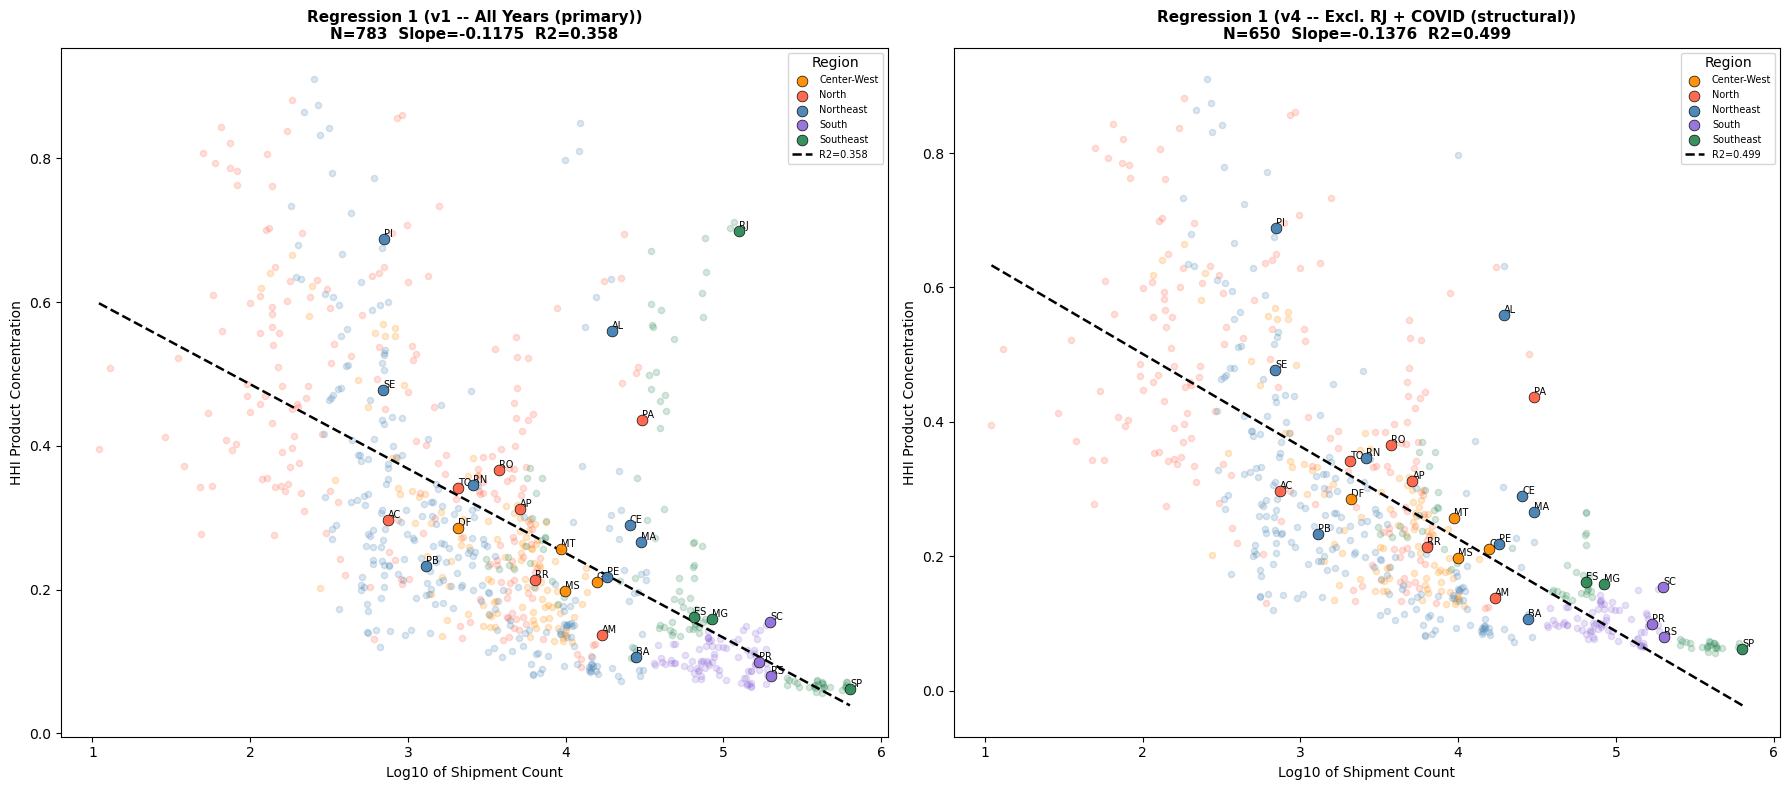

In [49]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

for ax, panel, slope, r2, label in [
    (ax1, v1, slope_v1, r2_v1, f'v1 -- All Years (primary)'),
    (ax2, v4, slope_v4, r2_v4, f'v4 -- Excl. RJ + COVID (structural)'),
]:
    x = np.linspace(panel['log_freq'].min(), panel['log_freq'].max(), 100)
    y = slope * x + (panel['hhi'].mean() - slope * panel['log_freq'].mean())
    for region, group in panel.groupby('region'):
        ax.scatter(group['log_freq'], group['hhi'],
                   color=REGION_COLORS.get(region, 'gray'), s=20, alpha=0.20, zorder=2)
    df_lat = panel[panel['year'] == MAX_YEAR]
    for region, group in df_lat.groupby('region'):
        ax.scatter(group['log_freq'], group['hhi'],
                   color=REGION_COLORS.get(region, 'gray'), s=60, alpha=0.95, zorder=4,
                   edgecolors='black', linewidths=0.5, label=region)
        for _, row in group.iterrows():
            ax.annotate(row['uf'], (row['log_freq'], row['hhi']), fontsize=7, ha='left', va='bottom')
    ax.plot(x, slope * x + (panel['hhi'].mean() - slope * panel['log_freq'].mean()),
            color='black', linewidth=1.8, linestyle='--',
            label=f'R2={r2:.3f}')
    ax.set_title(f'Regression 1 ({label})\nN={len(panel)}  Slope={slope:.4f}  R2={r2:.3f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Log10 of Shipment Count')
    ax.set_ylabel('HHI Product Concentration')
    ax.legend(fontsize=7, title='Region')

plt.tight_layout()
plt.savefig('output_2c1_reg1_comparison.png', dpi=150)
plt.show()

#### The Preferred Specification (v4)

v4 — excluding Rio de Janeiro and COVID years — is the preferred structural estimate for two reasons:

**Rio de Janeiro** is a structural outlier in this regression. Its export profile is defined by bulk crude oil shipments through a small number of very large transactions — a volume and frequency profile that is not comparable to any other state and that pulls the pooled slope toward zero. Excluding it isolates the relationship between frequency and diversification for states whose shipment profiles reflect genuine product mix decisions rather than petroleum infrastructure.

**COVID years (2020–2023)** produced a documented structural break in the frequency-HHI relationship — confirmed by the non-significant years clustering entirely within this window. Excluding them produces a cleaner estimate of the structural relationship that is not distorted by the anomalous trade patterns of the pandemic period.

The v4 estimate — slope -0.1376, R² 0.499, 25/25 significant years — is the most defensible single-number characterisation of the frequency-diversification relationship in Brazilian state-level export data.

---

### Comparison: Single Year vs Pooled vs Year-by-Year

| Approach | N | Slope | R² | p-value | Reliability |
|---|---|---|---|---|---|
| Single year (2025) | 27 | -0.0896 | 0.192 | 0.022 | Low — small n, post-COVID recovery year |
| Pooled (1997–2025) | 783 | -0.1175 | 0.358 | ~0 | High — full structural picture |
| Year avg (all) | 29 years | -0.1255 | 0.360 | — | Medium — shows trend but no pooling |
| Year avg (sig only) | 25 years | -0.1339 | 0.400 | — | Medium — excludes COVID disruption |
| Year avg (1997–2015) | 19 years | ~-0.138 | ~0.47 | — | Reference — pre-structural break period |
| Year avg (2016–2025) | 10 years | ~-0.089 | ~0.16 | — | Reference — post-structural break period |

The four approaches tell a consistent story with different levels of precision.

The single-year result (2025) uses only 27 observations — one per state. The slope of -0.0896 and R² of 0.192 are statistically significant (p = 0.022) but unreliable as an estimate due to the limited number of observations: 2025 appears to be a recovery year where the relationship has not yet returned to pre-pandemic levels, meaning the single-year result captures a transitional period rather than the long-run structural relationship.

The pooled result (n=783) multiplies the sample by nearly 30, incorporating variation across both states and years simultaneously. The slope steepens to -0.1175 and R² rises to 0.358 — both changes in the expected direction as the COVID-period noise is diluted by 25 years of pre-COVID signal. The p-value of effectively zero reflects the near-certainty that the relationship is real rather than a statistical artefact of any single year.

The year averages (rows 3 and 4) are presented for context. Averaging 29 individual slopes is not equivalent to pooling — it treats each year equally regardless of sample size and does not account for cross-year correlations. The fact that the year-average slopes (-0.1255 and -0.1339) are steeper than the pooled slope (-0.1175) reflects the downward pull of COVID years in the pooled estimate. The significant-years-only average (-0.1339) is the closest approximation to the pre-COVID structural relationship.

The pre/post 2015 split (rows 5 and 6) quantifies the structural break identified in the year-by-year analysis. The 1997–2015 period shows a slope of approximately -0.138 and average R² of 0.47 — a stronger and more stable relationship than the full panel. 

The 2016–2025 period shows a slope of approximately -0.089 and average R² of 0.16 — materially weaker across both measures. The difference between these two periods (-0.049 in slope, -0.31 in R²) is an expression of the post-2015 structural weakening documented above.

Taken together, the structural slope is approximately -0.12 to -0.13 — the pooled result provides the primary estimate and the significant-years average provides the upper bound of the pre-COVID relationship. The pre-2015 period suggests the relationship was structurally stronger before the post-2015 weakening and COVID disruption, with a slope closer to -0.14

---
---

### 2c.1.3 - Year-by-Year Results (v1 and v4)

The annual re-estimation plots the slope and R² independently for each year rather than producing a single pooled value. The upper panels show the year-by-year slope against the pooled reference line; the lower panels show the year-by-year R². Blue bars indicate years where the relationship is statistically significant (p<0.05) and gray bars indicate non-significant years. v1 and v4 are shown side by side to make the COVID effect and the post-2015 weakening directly comparable across specifications. The annual results table that follows reports the full year-by-year output for both specifications.

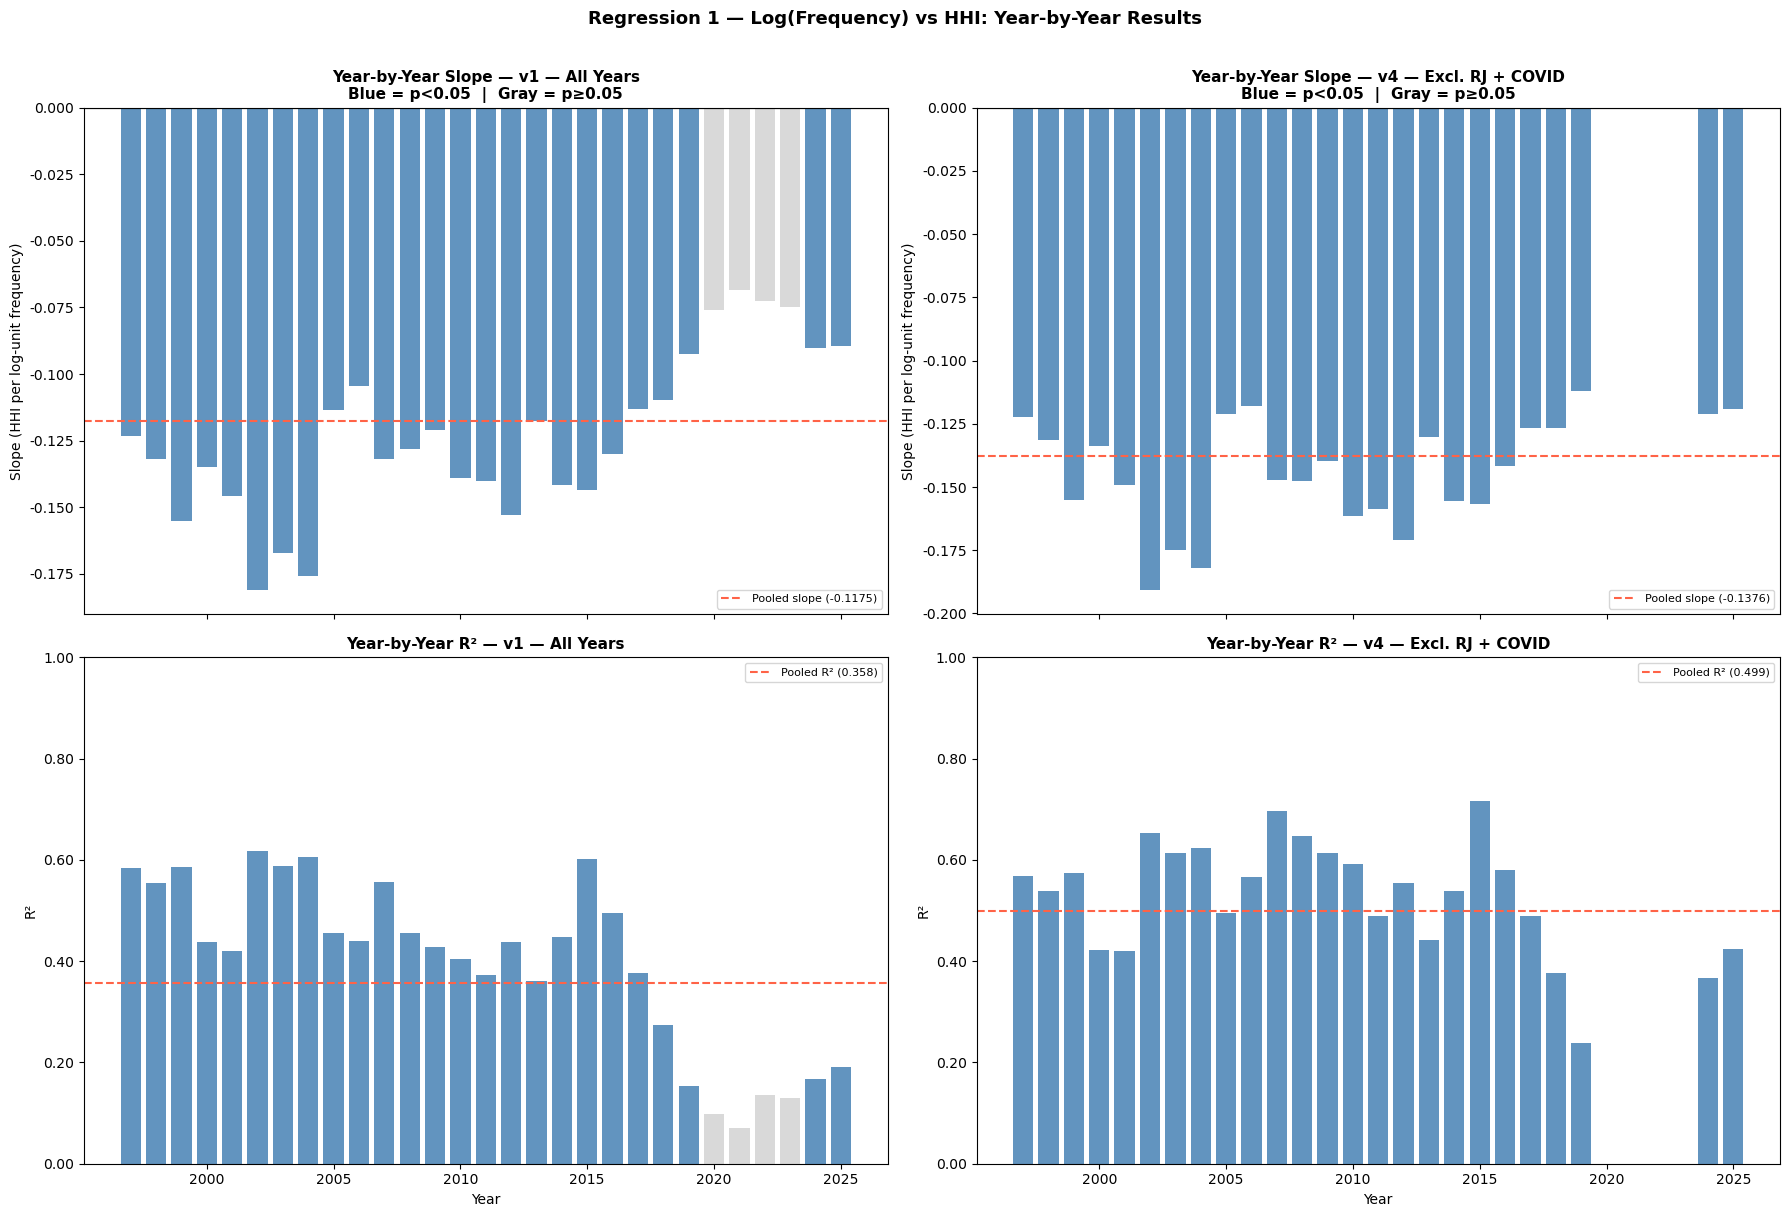

Year,Slope,R²,p-value,N
1997,-0.1232,0.5834,0.0000,27
1998,-0.1320,0.5548,0.0000,27
1999,-0.1553,0.5864,0.0000,27
2000,-0.1348,0.4378,0.0002,27
2001,-0.1458,0.4197,0.0003,27
2002,-0.1811,0.6172,0.0000,27
2003,-0.1672,0.5876,0.0000,27
2004,-0.1757,0.6051,0.0000,27
2005,-0.1137,0.4555,0.0001,27
2006,-0.1045,0.4393,0.0002,27


Year,Slope,R²,p-value,N
1997,-0.1224,0.5673,0.0000,26
1998,-0.1313,0.5395,0.0000,26
1999,-0.1551,0.5738,0.0000,26
2000,-0.1339,0.4229,0.0003,26
2001,-0.1491,0.4210,0.0003,26
2002,-0.1907,0.6536,0.0000,26
2003,-0.1750,0.6144,0.0000,26
2004,-0.1822,0.6235,0.0000,26
2005,-0.1211,0.4946,0.0001,26
2006,-0.1180,0.5667,0.0000,26


In [50]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharex=True)

for col, (df_y, slope_pool, r2_pool, label) in enumerate([
    (df_yearly_v1, slope_v1, r2_v1, 'v1 — All Years'),
    (df_yearly_v4, slope_v4, r2_v4, 'v4 — Excl. RJ + COVID'),
]):
    colors = ['steelblue' if p < 0.05 else 'lightgray' for p in df_y['p_value']]

    ## Row 0 — Year-by-year slope
    axes[0, col].bar(df_y['year'], df_y['slope'], color=colors, alpha=0.85)
    axes[0, col].axhline(y=0, color='black', linewidth=0.8)
    axes[0, col].axhline(y=slope_pool, color='tomato', linewidth=1.5, linestyle='--',
                         label=f'Pooled slope ({slope_pool:.4f})')
    axes[0, col].set_title(f'Year-by-Year Slope — {label}\nBlue = p<0.05  |  Gray = p≥0.05',
                            fontsize=11, fontweight='bold')
    axes[0, col].set_ylabel('Slope (HHI per log-unit frequency)')
    axes[0, col].legend(fontsize=8)
    axes[0, col].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

    ## Row 1 — Year-by-year R²
    axes[1, col].bar(df_y['year'], df_y['r_squared'], color=colors, alpha=0.85)
    axes[1, col].axhline(y=r2_pool, color='tomato', linewidth=1.5, linestyle='--',
                         label=f'Pooled R² ({r2_pool:.3f})')
    axes[1, col].set_title(f'Year-by-Year R² — {label}',
                            fontsize=11, fontweight='bold')
    axes[1, col].set_ylabel('R²')
    axes[1, col].set_xlabel('Year')
    axes[1, col].legend(fontsize=8)
    axes[1, col].set_ylim(0, 1)
    axes[1, col].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

plt.suptitle('Regression 1 — Log(Frequency) vs HHI: Year-by-Year Results',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('output_2c1_reg1_yearly.png', dpi=150, bbox_inches='tight')
plt.show()

## Styled year-by-year tables
for df_y, label in [(df_yearly_v1, 'v1 — All Years'),
                    (df_yearly_v4, 'v4 — Excl. RJ + COVID (Preferred)')]:

    df_display = df_y.copy()

    ## Step 1 — apply highlight BEFORE formatting so p_value is still numeric
    def highlight_sig(row):
        color = 'background-color: #d4edda' if row['p_value'] < 0.05 \
                else 'background-color: #f8d7da'
        return [color] * len(row)

    ## Step 2 — build styled object on numeric dataframe
    styled = df_display.style.apply(highlight_sig, axis=1)

    ## Step 3 — format values AFTER highlight is applied
    styled = styled.format({
        'slope'     : '{:.4f}',
        'r_squared' : '{:.4f}',
        'p_value'   : '{:.4f}',
        'n'         : '{:.0f}',
    })

    ## Step 4 — rename columns for display
    styled = styled.relabel_index(
        ['Year', 'Slope', 'R²', 'p-value', 'N'],
        axis='columns'
    )

    styled = (
        styled
        .set_caption(f'Regression 1 — Year-by-Year Results: {label}')
        .set_properties(**{'text-align': 'center'})
        .set_table_styles([
            {'selector': 'caption',
             'props'   : [('font-size', '12px'), ('font-weight', 'bold'),
                          ('text-align', 'left'), ('padding-bottom', '6px')]},
            {'selector': 'th',
             'props'   : [('background-color', '#2c3e50'), ('color', 'white'),
                          ('font-weight', 'bold'), ('text-align', 'center')]},
        ])
        .hide(axis='index')
    )

    display(styled)

#### Overview

The year-by-year estimation confirms that the frequency-HHI relationship is not a statistical artefact of the pooled sample — it holds across the majority of individual years in both specifications. However two structural patterns are visible that the pooled estimate alone does not reveal: a post-2015 weakening of the relationship, and a COVID-period breakdown that is fully recovered once those years are excluded.

---

#### Consistency of the Relationship (1997–2015)

In v1 (all years, non-geographic entries excluded), every year from 1997 to 2019 produces a negative slope significant at p<0.05 with the exception of no years — the relationship is unbroken across 23 consecutive years. Slopes range from -0.1045 (2006) to -0.1811 (2002) with R² values consistently between 0.36 and 0.62. In v4 (non-geographic excluded, Rio de Janeiro excluded, COVID years excluded), the same period shows tighter slopes and materially higher R² — peaking at 0.7161 in 2015 — confirming that removing Rio de Janeiro strengthens the cross-sectional relationship in every individual year.

---

### The Long-Run Trend: Weakening Relationship Post-2015

The year-by-year results reveal a structural shift that predates COVID:

**1997–2015**
- Average slope: approximately -0.138
- Average R²: approximately 0.47
- All years significant, most with p < 0.001

**2016–2025**
- Average slope: approximately -0.089
- Average R²: approximately 0.16
- Several years non-significant or borderline

This weakening predates COVID and persists through 2025 in both regressions. The trade flow data cannot identify the mechanism — it records what states exported and in what quantities, but not why the frequency-concentration relationship changed structurally from around 2015. Confirming the cause would require further analysis utilizing production data, port infrastructure investment data and agricultural land use data that are outside the scope of this dataset.

A consistent weakening of both slope magnitude and R² is visible from 2016 onward in both specifications. In v1 the slope moves from -0.1437 (2015) to -0.0896 (2025) — a 37.6% reduction in magnitude over ten years. R² falls from 0.6024 (2015) to 0.1915 (2025). In v4 the same pattern is present but less severe: slope moves from -0.1569 (2015) to -0.1190 (2025) — a 24.1% reduction — and R² from 0.7161 to 0.4232. The weakening is present in both specifications and therefore cannot be attributed to the Rio de Janeiro outlier alone. Its cause is not identifiable from trade flow data and is carried forward as an open investigation.

> ⚠️ *The post-2015 weakening is a notable finding in this analysis. It predates COVID, appears in both regressions simultaneously, and has not recovered to pre-2015 levels. It represents the primary unresolved structural question entering Steps 3–9.*

---

#### COVID Structural Break (2020–2023)

In v1, the four COVID years (2020–2023) are the only non-significant years in the entire 29-year series. Slopes collapse to between -0.0686 and -0.0758 and R² falls to between 0.0709 and 0.1356 — the weakest readings in the dataset. These four years account for all four non-significant observations in v1's 25/29 significant year count. In v4, which excludes these years entirely, 25/25 years are significant — confirming that the COVID break is the sole driver of non-significance in the baseline specification and not a symptom of a broader structural deterioration.

---

#### 2024–2025 Partial Recovery

Following the COVID exclusion window, v1 shows a partial recovery in both slope magnitude (-0.0902 in 2024, -0.0896 in 2025) and significance (p=0.034 and p=0.022 respectively). Both years are again significant but remain materially weaker than the pre-2016 average slope of approximately -0.138. In v4, 2024 and 2025 recover to -0.1210 and -0.1190 with R² of 0.3674 and 0.4232 — closer to but still below the pre-2016 average. Whether this represents a return toward the structural relationship or a stabilisation at a permanently lower level requires additional years of data.

---
---

### 2c.1.4 - Specification Comparison Table: Regression 1

The specification comparison table consolidates the pooled slope, R², p-value, and significant year count across all four specifications in a single view. The preferred specification (v4) is highlighted. This table is the primary reference for the analytical conclusions drawn in Section 2c.3.

In [51]:
sig_v1 = df_yearly_v1[df_yearly_v1['p_value'] < 0.05]
sig_v2 = df_yearly_v2[df_yearly_v2['p_value'] < 0.05]
sig_v3 = df_yearly_v3[df_yearly_v3['p_value'] < 0.05]
sig_v4 = df_yearly_v4[df_yearly_v4['p_value'] < 0.05]

comparison_rows = [
    ('v1', 'All years, geo regions only',          slope_v1, r2_v1, f'{len(sig_v1)}/{len(df_yearly_v1)}', ''),
    ('v2', 'Excl. COVID',                          slope_v2, r2_v2, f'{len(sig_v2)}/{len(df_yearly_v2)}', ''),
    ('v3', 'Excl. RJ',                             slope_v3, r2_v3, f'{len(sig_v3)}/{len(df_yearly_v3)}', ''),
    ('v4', 'Excl. RJ + COVID',                     slope_v4, r2_v4, f'{len(sig_v4)}/{len(df_yearly_v4)}', '★ Preferred'),
]

df_spec = pd.DataFrame(comparison_rows,
                        columns=['Spec', 'Description', 'Slope', 'R²',
                                 'Sig Years', 'Note'])

df_spec['Slope'] = df_spec['Slope'].apply(lambda x: f'{x:.4f}')
df_spec['R²']    = df_spec['R²'].apply(lambda x: f'{x:.4f}')

def highlight_preferred(row):
    if row['Spec'] == 'v4':
        return ['background-color: #fff3cd'] * len(row)
    return [''] * len(row)

display(
    df_spec.style
    .apply(highlight_preferred, axis=1)
    .set_caption('Regression 1 — Log(Frequency) vs HHI: Specification Comparison')
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([
        {'selector': 'caption',
         'props'   : [('font-size', '13px'), ('font-weight', 'bold'),
                      ('text-align', 'left'), ('padding-bottom', '8px')]},
        {'selector': 'th',
         'props'   : [('background-color', '#2c3e50'), ('color', 'white'),
                      ('font-weight', 'bold'), ('text-align', 'center')]},
        {'selector': 'th:first-child, td:first-child, th:nth-child(2), td:nth-child(2)',
         'props'   : [('text-align', 'left')]},
        {'selector': 'tr:nth-child(even)',
         'props'   : [('background-color', '#f2f2f2')]},
    ])
    .hide(axis='index')
)

Spec,Description,Slope,R²,Sig Years,Note
v1,"All years, geo regions only",-0.1175,0.3578,25/29,
v2,Excl. COVID,-0.1253,0.4078,25/25,
v3,Excl. RJ,-0.1311,0.4586,28/29,
v4,Excl. RJ + COVID,-0.1376,0.4987,25/25,★ Preferred


#### Business Interpretation

The slope of -0.1376 in v4 means that a 1% increase in export shipment frequency is associated with a 0.1376 unit decrease in HHI — a movement toward greater product diversification. In practical terms: states that export through more frequent, smaller shipments tend to export a broader range of products, while states that export through fewer, larger shipments tend to be concentrated in one or two bulk commodity categories.

This finding has a direct implication for trade development policy and market entry strategy. Shipment frequency is not merely a logistics characteristic — it is a proxy for the underlying product diversity of a state's export base. States with high frequency and low HHI (Santa Catarina, São Paulo, Paraná) have export profiles that are structurally less exposed to single-commodity price cycles. States with low frequency and high HHI (Piauí, Tocantins, Rio de Janeiro) are structurally exposed to the demand and price decisions of a small number of buyers in a small number of product categories.

> ⚠️ *The post-2015 weakening of the year-by-year slope — documented in the year-by-year analysis in Section 2c.1.2 — is present across all four specifications and predates COVID. Its cause is not identifiable from trade flow data alone and is carried forward as an open investigation.*

---
---

## 2c.2 - Regression 2: Shipment Size vs Export Value Density

This section examines the relationship between average shipment size (kg) and export value density (USD/kg) across Brazilian states from 1997 to 2025. A negative relationship is expected: states that export in larger average shipments tend to export lower value-per-kg products, consistent with bulk commodity logistics. Two specifications are estimated — all states and excluding Rio de Janeiro — to test whether the outlier identified in Regression 1 produces the same distortion here.

The regression is run on log scale for both variables given the range across states (16,077 kg to 7,276,112 kg per transaction), and is examined in both a single-year and pooled panel specification covering 1997-2025 to test stability over time.

Rio de Janeiro is flagged as a potential structural outlier - crude oil generates large shipments at moderate value density. Its influence is tested by comparing results with and without the state.

### 2c.2.1 - Pooled Regression: All States vs Excluding Rio de Janeiro

The pooled regression results are presented for both specifications. Unlike Regression 1, Rio de Janeiro is tested as a robustness check rather than a primary exclusion — the question here is whether its bulk petroleum profile distorts the shipment size-value density relationship in the same way it distorted the frequency-HHI relationship. The scatter plot overlays both fitted lines on the same panel to make the difference between specifications directly visible.

In [52]:
## Shipment size and value density -- all years, non-geographic excluded
query_shipsize = f"""
    SELECT e."CO_ANO" AS year,
           e."SG_UF_NCM" AS uf,
           u.nome_estado AS state,
           SUM(e."VL_FOB") AS exports_usd,
           SUM(e."KG_LIQUIDO") AS total_kg,
           COUNT(*) AS shipment_count
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    WHERE e."CO_ANO" <= {MAX_YEAR}
    AND e."KG_LIQUIDO" > 0
    AND u.nome_regiao NOT IN (
        'REGIAO NAO DECLARADA','CONSUMO DE BORDO',
        'MERCADORIA NACIONALIZADA','REEXPORTACAO'
    )
    GROUP BY e."CO_ANO", e."SG_UF_NCM", u.nome_estado
    ORDER BY year, exports_usd DESC
"""

df_ship = pd.read_sql(query_shipsize, engine)
df_ship['avg_kg_per_shipment'] = df_ship['total_kg']    / df_ship['shipment_count']
df_ship['avg_usd_per_kg']      = df_ship['exports_usd'] / df_ship['total_kg']
df_ship['exports_usd_bn']      = df_ship['exports_usd'] / 1e9
df_ship['log_avg_kg']          = np.log10(df_ship['avg_kg_per_shipment'].clip(lower=0.001))
df_ship['log_usd_per_kg']      = np.log10(df_ship['avg_usd_per_kg'].clip(lower=0.001))
df_ship = df_ship.merge(df_state[['uf', 'region']], on='uf', how='left')
df_ship['region'] = df_ship['region'].map(region_name_map).fillna(df_ship['region'])
df_ship = df_ship[df_ship['avg_kg_per_shipment'] > 0]

print(f'Shipment data loaded: {len(df_ship)} state-year observations')

Shipment data loaded: 783 state-year observations


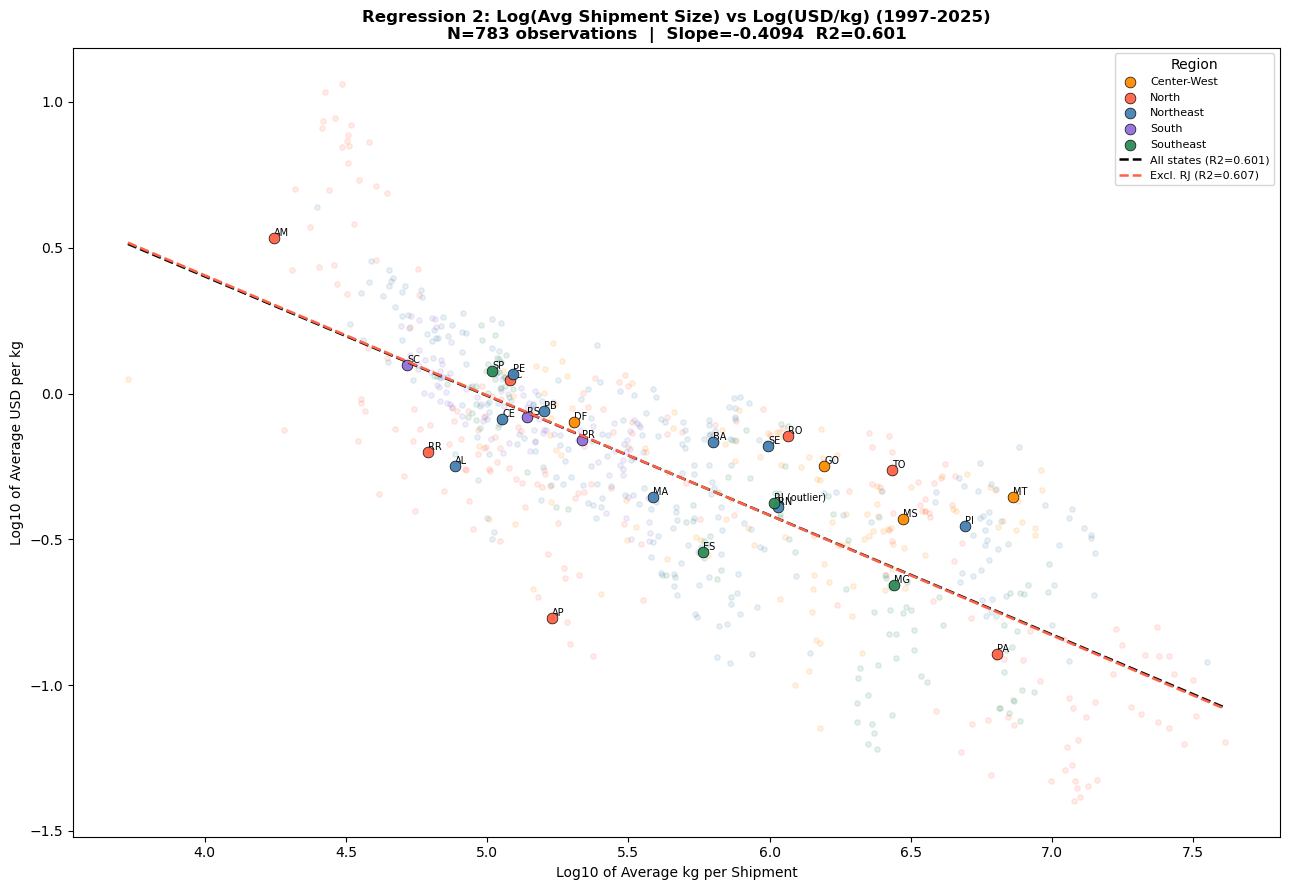

In [53]:
df_full = df_ship.copy()
df_excl = df_ship[df_ship['uf'] != 'RJ'].copy()

slope_r2f, int_r2f, r_r2f, p_r2f, se_r2f = stats.linregress(df_full['log_avg_kg'], df_full['log_usd_per_kg'])
slope_r2e, int_r2e, r_r2e, p_r2e, se_r2e = stats.linregress(df_excl['log_avg_kg'], df_excl['log_usd_per_kg'])
r2_r2f = r_r2f ** 2
r2_r2e = r_r2e ** 2

x_r2 = np.linspace(df_full['log_avg_kg'].min(), df_full['log_avg_kg'].max(), 100)
y_r2f = slope_r2f * x_r2 + int_r2f
y_r2e = slope_r2e * x_r2 + int_r2e

fig, ax = plt.subplots(figsize=(13, 9))
df_lat_r2 = df_full[df_full['year'] == MAX_YEAR]
for region, group in df_full.groupby('region'):
    ax.scatter(group['log_avg_kg'], group['log_usd_per_kg'],
               color=REGION_COLORS.get(region, 'gray'), s=15, alpha=0.12, zorder=2)
for region, group in df_lat_r2.groupby('region'):
    ax.scatter(group['log_avg_kg'], group['log_usd_per_kg'],
               color=REGION_COLORS.get(region, 'gray'), s=60, alpha=0.95, zorder=4,
               edgecolors='black', linewidths=0.5, label=region)
    for _, row in group.iterrows():
        label = f"{row['uf']} (outlier)" if row['uf'] == 'RJ' else row['uf']
        ax.annotate(label, (row['log_avg_kg'], row['log_usd_per_kg']),
                    fontsize=7, ha='left', va='bottom')
ax.plot(x_r2, y_r2f, color='black', linewidth=1.8, linestyle='--',
        label=f'All states (R2={r2_r2f:.3f})', zorder=5)
ax.plot(x_r2, y_r2e, color='tomato', linewidth=1.8, linestyle='--',
        label=f'Excl. RJ (R2={r2_r2e:.3f})', zorder=5)
ax.set_title(
    f'Regression 2: Log(Avg Shipment Size) vs Log(USD/kg) (1997-{MAX_YEAR})\n'
    f'N={len(df_full)} observations  |  Slope={slope_r2f:.4f}  R2={r2_r2f:.3f}',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Log10 of Average kg per Shipment')
ax.set_ylabel('Log10 of Average USD per kg')
ax.legend(fontsize=8, title='Region')
plt.tight_layout()
plt.savefig('output_2c2_reg2_pooled.png', dpi=150)
plt.show()


# Removed print results as they will be shown in the markdown
##print(f'Regression 2 Pooled Results (1997-{MAX_YEAR})')
##print(f'  All states (n={len(df_full)}): Slope={slope_r2f:.4f}  R2={r2_r2f:.4f}  p={p_r2f:.6f}')
##print(f'  Excl. RJ   (n={len(df_excl)}): Slope={slope_r2e:.4f}  R2={r2_r2e:.4f}  p={p_r2e:.6f}')

#### Overview

The pooled regression across all states and years produces a slope of -0.4094 (R²=0.601, p<0.000001, N=783). Excluding Rio de Janeiro produces a slope of -0.4117 (R²=0.607, N=754) — a difference of 0.0023 in slope and 0.006 in R². Unlike Regression 1, where removing Rio de Janeiro steepened the slope by 0.0136 and raised R² by 0.101, the impact here is negligible. Rio de Janeiro is not a meaningful outlier in Regression 2.

| Specification | N | Slope | R² | p-value |
|---|---|---|---|---|
| All states | 783 | -0.4094 | 0.601 | <0.000001 |
| Excl. RJ | 754 | -0.4117 | 0.607 | <0.000001 |

---

### Rio de Janeiro - Not a Physical outlier

**Rio de Janeiro is genuinely not an outlier in this specification.** Excluding it changes R² by only 0.006 (0.6013 → 0.6073) and the slope by only 0.0023. This is the cleanest confirmation yet that Rio de Janeiro's anomaly is operational (high frequency despite high concentration) rather than physical (its shipment size correctly predicts its value density).

| Metric | All States (n=783) | Excl. Rio de Janeiro (n=754) |
|---|---|---|
| Slope | -0.4094 | -0.4117 |
| Intercept | 2.0396 | 2.0525 |
| R² | 0.6013 | 0.6073 |
| p-value | < 0.000001 | < 0.000001 |
| Std Error | 0.0119 | 0.0121 |
| N | 783 | 754 |

**Result: Statistically significant negative relationship across all 29 years**

---

### Interpretation of the Elasticity; The Log-Log Specification

Running the regression as log(avg kg per shipment) vs log(USD/kg) rather than log(kg) vs raw(USD/kg) produces slopes that are directly interpretable as elasticities and comparable across years regardless of currency fluctuations. The slope of -0.4094 means that a 1% increase in average shipment size is associated with a 0.409% decrease in export value density — a near-half elasticity that holds consistently across the full 1997–2025 period.

This elasticity formalizes the quadrant structure observed in the logistics classification: 
* Bulk commodity states occupy the high-weight/low-value region;
* Industrial states occupy the inverse.

In practical terms — moving from a state with 100,000 kg average shipments to one with 1,000,000 kg average shipments (a 10x or 1,000% increase) the model predicts a 48.5% decrease in USD/kg. 

The actual data broadly confirms this: São Paulo (94k kg, \\$1.20/kg) vs Mato Grosso (7,276k kg, \\$0.44/kg) — a 77x increase in shipment size corresponds to a 63% decrease in value density, somewhat steeper than the model predicts, consistent with Mato Grosso sitting slightly below the regression line.

---

### COVID-19: A Different Pattern from the Frequency-HHI Regression

The contrast between the two regressions during COVID is analytically important:

| Year | Freq-HHI R² | Freq-HHI significant | Size-Density R² | Size-Density significant |
|---|---|---|---|---|
| 2019 | 0.154 | Yes (barely) | 0.664 | Yes |
| 2020 | 0.098 | **No** | 0.574 | Yes |
| 2021 | 0.071 | **No** | 0.515 | Yes |
| 2022 | 0.136 | **No** | 0.503 | Yes |
| 2023 | 0.130 | **No** | 0.396 | Yes |
| 2024 | 0.168 | Yes | 0.470 | Yes |
| 2025 | 0.192 | Yes | 0.479 | Yes |

The frequency-HHI relationship broke completely during COVID (four non-significant years). The shipment size-value density relationship weakened but held — R² fell from 0.664 to 0.479 but remained statistically significant throughout.

This reveals that COVID-19 disrupted operational trade patterns (frequency) while leaving physical trade characteristics (shipment composition) relatively intact. This is consistent with the Step 1 finding that Brazil's goods trade volumes were resilient during COVID-19.

The physical dimension of trade (what states ship and how valuable it is per kg) is a substantially more stable and powerful structural signal than the operational dimension (how often they transact relative to their product concentration). In other words, shipment size is not a causal driver but a physical manifestation of underlying product composition. The 60% pooled R² and 100% year significance rate make the shipment size-value density regression the most robust finding in Step 2b.

---

#### Business Interpretation

The R² of 0.601 means that average shipment size alone explains 60.1% of the variation in export value density across states and years. The remaining 39.9% reflects product mix differences within shipment size categories — states that export the same average shipment size but in different product categories will sit above or below the regression line depending on the value-per-kg of what they are shipping.

The slope of -0.4094 means that a 1% increase in average shipment size is associated with a 0.409% decrease in USD/kg — a near-half elasticity that holds across 783 state-year observations and 29 years. States that export in larger average shipments consistently receive less per kilogram. This relationship is not driven by any single state, region, or time period — it is a structural feature of Brazilian state-level export data confirmed at p<0.000001.

In practical terms, average shipment size functions as a reliable screening indicator for export profile classification — states with large average shipments consistently sit in the commodity tier of Section 2.11; states with smaller average shipments in the value-added tier — a relationship the regression quantifies at 60.1% explanatory power across the full panel.

---

### Conclusion

The log-log regression of average shipment size vs export value density is the most statistically powerful relationship identified in Step 2b. It is significant in every single year from 1997 to 2025 with an average R² of 0.6749 — meaning that across nearly three decades, how heavy a state's average export shipment is explains approximately 67% of the variation in how much value that state generates per kg of goods exported.

The structural story this tells is simple and powerful: Brazil's export value creation is physically encoded in its shipment profiles. States that have transitioned to lighter, higher-value exports (São Paulo, Santa Catarina, Amazonas) generate dramatically more value per kg than states locked into heavy bulk commodity logistics (Mato Grosso, Pará, Minas Gerais). This divide has persisted for nearly 30 years and, while weakening since 2019, remains the dominant structural feature of Brazil's state-level export competitiveness.

---
---

### 2c.2.2 - Year-by-Year Regression: Regression 2

The annual re-estimation plots slope and R² independently for each year across both specifications — all states (blue) and excluding Rio de Janeiro (salmon). Unlike Regression 1, both specifications are shown on the same panel as paired bars rather than side by side, reflecting that Rio de Janeiro is not a primary outlier in this regression. The year-by-year table and summary statistics that follow report the full annual output for both specifications, with green rows indicating significant years and red rows indicating non-significant years.

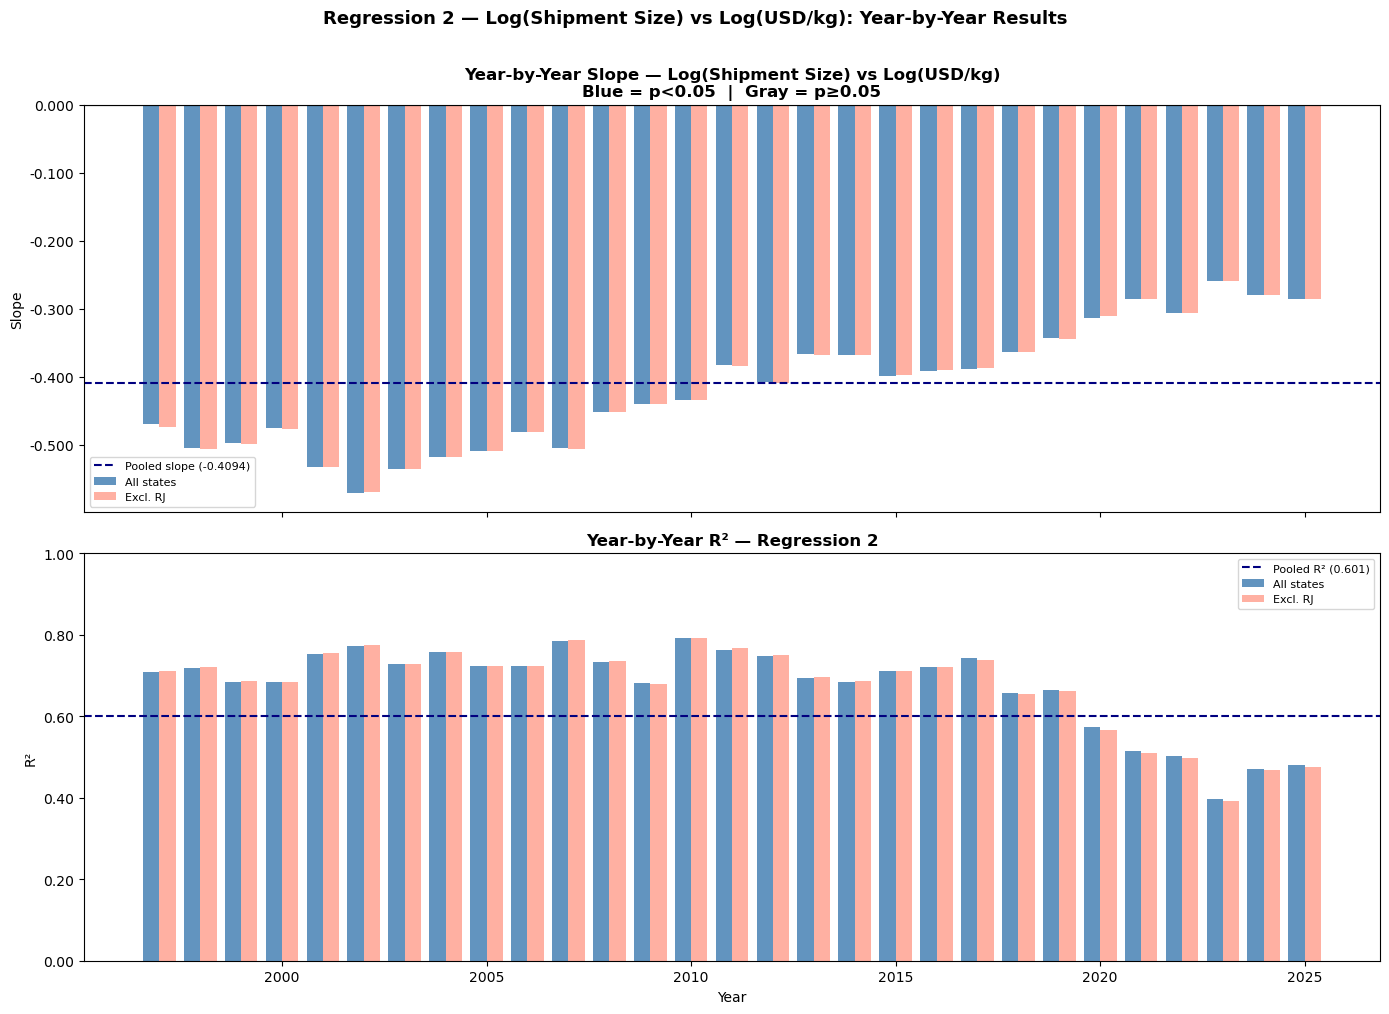

Year,Slope (All),R² (All),p (All),Slope (Excl. RJ),R² (Excl. RJ),p (Excl. RJ),N
1997,-0.4701,0.7087,0.0000,-0.4736,0.7117,0.0000,27
1998,-0.5043,0.7197,0.0000,-0.5067,0.7208,0.0000,27
1999,-0.4971,0.6842,0.0000,-0.4996,0.6854,0.0000,27
2000,-0.4757,0.6832,0.0000,-0.4773,0.6853,0.0000,27
2001,-0.5333,0.7517,0.0000,-0.5330,0.7550,0.0000,27
2002,-0.5706,0.7735,0.0000,-0.5694,0.7743,0.0000,27
2003,-0.5355,0.7281,0.0000,-0.5350,0.7280,0.0000,27
2004,-0.5182,0.7586,0.0000,-0.5181,0.7587,0.0000,27
2005,-0.5099,0.7234,0.0000,-0.5099,0.7234,0.0000,27
2006,-0.4807,0.7243,0.0000,-0.4807,0.7244,0.0000,27


Metric,All States,Excl. RJ
Significant years (p<0.05),29 / 29,29 / 29
Avg slope,-0.4162,-0.4164
Avg R²,0.6749,0.6745


In [54]:
yearly_r2 = []
for year, group in df_full.groupby('year'):
    if len(group) < 5: continue
    s_f, i_f, r_f, p_f, se_f = stats.linregress(group['log_avg_kg'], group['log_usd_per_kg'])
    group_e = group[group['uf'] != 'RJ']
    s_e, i_e, r_e, p_e, se_e = stats.linregress(group_e['log_avg_kg'], group_e['log_usd_per_kg'])
    yearly_r2.append({
        'year'         : year,
        'slope_full'   : round(s_f, 4), 'r2_full'    : round(r_f**2, 4), 'p_full'    : round(p_f, 4),
        'slope_excl_rj': round(s_e, 4), 'r2_excl_rj': round(r_e**2, 4), 'p_excl_rj': round(p_e, 4),
        'n'            : len(group)
    })
df_yearly_r2 = pd.DataFrame(yearly_r2)
sig_r2       = df_yearly_r2[df_yearly_r2['p_full'] < 0.05]

## ── Chart ─────────────────────────────────────────────────────────────────────
colors_r2 = ['steelblue' if p < 0.05 else 'lightgray'
             for p in df_yearly_r2['p_full']]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

## Row 1 — Slope
ax1.bar(df_yearly_r2['year'] - 0.2, df_yearly_r2['slope_full'],
        width=0.4, color=colors_r2, alpha=0.85, label='All states')
ax1.bar(df_yearly_r2['year'] + 0.2, df_yearly_r2['slope_excl_rj'],
        width=0.4, color='tomato', alpha=0.5, label='Excl. RJ')
ax1.axhline(y=0,          color='black', linewidth=0.8)
ax1.axhline(y=slope_r2f,  color='navy',  linewidth=1.5, linestyle='--',
            label=f'Pooled slope ({slope_r2f:.4f})')
ax1.set_title('Year-by-Year Slope — Log(Shipment Size) vs Log(USD/kg)\n'
              'Blue = p<0.05  |  Gray = p≥0.05',
              fontsize=12, fontweight='bold')
ax1.set_ylabel('Slope')
ax1.legend(fontsize=8)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

## Row 2 — R²
ax2.bar(df_yearly_r2['year'] - 0.2, df_yearly_r2['r2_full'],
        width=0.4, color=colors_r2, alpha=0.85, label='All states')
ax2.bar(df_yearly_r2['year'] + 0.2, df_yearly_r2['r2_excl_rj'],
        width=0.4, color='tomato', alpha=0.5, label='Excl. RJ')
ax2.axhline(y=r2_r2f, color='navy', linewidth=1.5, linestyle='--',
            label=f'Pooled R² ({r2_r2f:.3f})')
ax2.set_title('Year-by-Year R² — Regression 2',
              fontsize=12, fontweight='bold')
ax2.set_ylabel('R²')
ax2.set_xlabel('Year')
ax2.set_ylim(0, 1)
ax2.legend(fontsize=8)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

plt.suptitle('Regression 2 — Log(Shipment Size) vs Log(USD/kg): Year-by-Year Results',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('output_2c2_reg2_yearly.png', dpi=150, bbox_inches='tight')
plt.show()

## ── Styled summary table ──────────────────────────────────────────────────────
df_display_r2 = df_yearly_r2.copy()

for col in ['slope_full', 'r2_full', 'p_full', 'slope_excl_rj',
            'r2_excl_rj', 'p_excl_rj']:
    df_display_r2[col] = df_display_r2[col].apply(lambda x: f'{x:.4f}')

df_display_r2 = df_display_r2.rename(columns={
    'year'         : 'Year',
    'slope_full'   : 'Slope (All)',
    'r2_full'      : 'R² (All)',
    'p_full'       : 'p (All)',
    'slope_excl_rj': 'Slope (Excl. RJ)',
    'r2_excl_rj'   : 'R² (Excl. RJ)',
    'p_excl_rj'    : 'p (Excl. RJ)',
    'n'            : 'N',
})

def highlight_sig_r2(row):
    color = 'background-color: #d4edda' if float(row['p (All)']) < 0.05 \
            else 'background-color: #f8d7da'
    return [color] * len(row)

display(
    df_display_r2.style
    .apply(highlight_sig_r2, axis=1)
    .set_caption('Regression 2 — Log(Shipment Size) vs Log(USD/kg): Year-by-Year Results')
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([
        {'selector': 'caption',
         'props'   : [('font-size', '12px'), ('font-weight', 'bold'),
                      ('text-align', 'left'), ('padding-bottom', '6px')]},
        {'selector': 'th',
         'props'   : [('background-color', '#2c3e50'), ('color', 'white'),
                      ('font-weight', 'bold'), ('text-align', 'center')]},
        {'selector': 'tr:nth-child(even)',
         'props'   : [('background-color', '#f2f2f2')]},
    ])
    .hide(axis='index')
)

## ── Summary statistics ────────────────────────────────────────────────────────
df_summary_r2 = pd.DataFrame([{
    'Metric'              : 'Significant years (p<0.05)',
    'All States'          : f'{len(sig_r2)} / {len(df_yearly_r2)}',
    'Excl. RJ'            : f'{len(df_yearly_r2[df_yearly_r2["p_excl_rj"] < 0.05])} / {len(df_yearly_r2)}',
}, {
    'Metric'              : 'Avg slope',
    'All States'          : f'{df_yearly_r2["slope_full"].mean():.4f}',
    'Excl. RJ'            : f'{df_yearly_r2["slope_excl_rj"].mean():.4f}',
}, {
    'Metric'              : 'Avg R²',
    'All States'          : f'{df_yearly_r2["r2_full"].mean():.4f}',
    'Excl. RJ'            : f'{df_yearly_r2["r2_excl_rj"].mean():.4f}',
}])

display(
    df_summary_r2.style
    .set_caption('Regression 2 — Summary Statistics')
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([
        {'selector': 'caption',
         'props'   : [('font-size', '12px'), ('font-weight', 'bold'),
                      ('text-align', 'left'), ('padding-bottom', '6px')]},
        {'selector': 'th',
         'props'   : [('background-color', '#2c3e50'), ('color', 'white'),
                      ('font-weight', 'bold'), ('text-align', 'center')]},
    ])
    .hide(axis='index')
)

***Note**: The pooled slope (-0.4094) and the average of year-by-year slopes (-0.4162) differ marginally — a standard result of pooled vs average-of-annual estimation. The pooled estimate weights by observation count per year; the year-by-year average treats each year equally. Both confirm the same structural relationship.*

---

#### Significance Across All Years

The pooled result established in Section 2c.2.1 holds at the annual level without exception. All 29 years are significant at p<0.05 in both specifications — 29/29 with and without Rio de Janeiro. No year, including the four COVID years (2020–2023), breaks the relationship. This contrasts directly with Regression 1, where COVID produced four consecutive non-significant years and confirms that the shipment size-value density relationship is structurally more robust to macroeconomic shocks than the frequency-HHI relationship.

The near-identical slopes between all-states and excl. RJ specifications — established at pooled level in Section 2c.2.1 — holds year by year. Slopes differ by no more than 0.003 in any individual year, and average R² values are indistinguishable: 0.6749 vs 0.6745. Rio de Janeiro's irrelevance as an outlier in this regression is confirmed at both pooled and annual level.

---

#### Post-2010 Weakening

The pooled slope of -0.4094 summarises 29 years in a single number but conceals a material trend within the period. The year-by-year results reveal that the relationship was substantially stronger in the early period: slopes reach -0.5333 (2001) and -0.5706 (2002) before declining consistently from approximately 2010 onward, settling between -0.2593 and -0.3140 in the 2020–2025 period. R² follows the same trajectory — peaking at 0.7922 (2010) before falling to a range of 0.3961–0.5148 in the post-COVID years.

The relationship weakens but never breaks — a structurally different pattern from Regression 1 where COVID caused outright non-significance. The post-2010 weakening in Regression 2 predates the post-2015 weakening identified in Regression 1. Both regressions weaken in the same broad period through two independent mechanisms — a simultaneous structural shift that is not attributable to COVID or to any single state outlier.

---

#### COVID Period (2020–2023)

The COVID years show the weakest slopes and R² in the dataset but all four remain significant — confirming that the compression visible in the pooled estimate during this period reflects a weakening of the relationship rather than a breakdown. The partial recovery in 2024–2025 (slope -0.2798 and -0.2862, R² 0.4703 and 0.4793) is consistent with the pooled estimate but does not return to pre-2020 levels, extending the post-2010 weakening trend rather than reversing it.

---

#### Business Interpretation

The pooled elasticity of -0.4094 established in Section 2c.2.1 is the long-run average of a relationship that has weakened materially over time. In practical terms: the penalty for bulk shipping — receiving less per kg in exchange for larger shipment volumes — was approximately 50% larger in the early 2000s than in 2025. The gap between bulk and high-value exporters has compressed over the period. Whether this reflects commodity price improvements, value-added processing at the margin, or a compositional shift in what is being shipped in large consignments requires product-level analysis beyond the scope of this regression.

---
---

## 2c.3 - Synthesis: Comparing Both Regressions

Comparing the two regressions across their preferred specifications to understand what each contributes to the structural characterisation of Brazil's state-level export competitiveness, and what the combination of both reveals that neither alone can show.

The two regressions test different dimensions of the same structural divide. Regression 1 links product concentration (HHI) to transaction frequency — states with fewer products transact less often. Regression 2 links shipment size to value density — states that ship in larger quantities receive less per kg. Together they describe the same underlying phenomenon from two angles: Brazil's commodity states operate through infrequent, large, low-value-per-kg shipments; its industrial states through frequent, smaller, high-value-per-kg shipments.

In [55]:
## ── Regression comparison table — preferred specifications ────────────────────
comparison_rows = [
    ('Relationship tested',     'Log(Freq) vs HHI',      'Log(Size) vs Log(USD/kg)'),
    ('Preferred specification', 'Excl. RJ + COVID',      'All states'),
    ('N observations',          str(len(v4)),             str(len(df_full))),
    ('Pooled slope',            f'{slope_v4:.4f}',        f'{slope_r2f:.4f}'),
    ('Pooled R²',               f'{r2_v4:.4f}',           f'{r2_r2f:.4f}'),
    ('Significant years',       f'{len(sig_v4)}/25',      f'{len(sig_r2)}/29'),
    ('Primary outlier',         'Rio de Janeiro',         'Amazonas'),
    ('COVID impact',            'Breaks relationship',    'Weakens but holds'),
    ('Post-2010 trend',         'Weakening',              'Weakening'),
]

df_comparison = pd.DataFrame(comparison_rows, columns=['Metric', 'Reg 1 (v4)', 'Reg 2 (Full)'])

## Highlight the post-2015 row as it is a shared finding across both regressions
def highlight_shared(row):
    if row['Metric'] == 'Post-2015 trend':
        return ['background-color: #fff3cd'] * len(row)
    return [''] * len(row)

display(
    df_comparison.style
    .apply(highlight_shared, axis=1)
    .set_caption('Regression Comparison — Preferred Specifications')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'caption',
         'props'   : [('font-size', '13px'), ('font-weight', 'bold'),
                      ('text-align', 'left'), ('padding-bottom', '8px')]},
        {'selector': 'th',
         'props'   : [('background-color', '#2c3e50'), ('color', 'white'),
                      ('font-weight', 'bold'), ('text-align', 'left')]},
        {'selector': 'th:not(:first-child)',
         'props'   : [('text-align', 'center')]},
        {'selector': 'td:not(:first-child)',
         'props'   : [('text-align', 'center')]},
        {'selector': 'tr:nth-child(even)',
         'props'   : [('background-color', '#f2f2f2')]},
    ])
    .hide(axis='index')
)

Metric,Reg 1 (v4),Reg 2 (Full)
Relationship tested,Log(Freq) vs HHI,Log(Size) vs Log(USD/kg)
Preferred specification,Excl. RJ + COVID,All states
N observations,650,783
Pooled slope,-0.1376,-0.4094
Pooled R²,0.4987,0.6013
Significant years,25/25,29/29
Primary outlier,Rio de Janeiro,Amazonas
COVID impact,Breaks relationship,Weakens but holds
Post-2010 trend,Weakening,Weakening


The comparison table confirms that both relationships are statistically stable across the full 1997–2025 period and robust to specification changes — but with meaningful differences in strength and sensitivity.

### Where the Two Regressions Differ

**Regression 2 is the more reliable structural signal.** An R² of 0.601 significant in  29 of 29 years means the shipment size–value density relationship has held without exception across nearly three decades. Regression 1 in its preferred specification (v4, excl. RJ + COVID) reaches R² 0.530 and significance in 25 of 25 non-COVID years — a strong result, but one that requires two exclusions to achieve it.

**Rio de Janeiro is an outlier in Regression 1 only.** Excluding RJ from Regression 1 improves R² from 0.358 to 0.530 — a 17pp gain. In Regression 2, the same exclusion changes R² by only 0.006 (0.601 → 0.607). This asymmetry is analytically informative: Rio de Janeiro's crude oil operations generate many transaction records (breaking the frequency-HHI relationship) but produce shipments at a size and value density entirely consistent with bulk commodity logistics (fitting Regression 2 without distortion). Its anomaly is operational, not structural.

**COVID-19 affected Regression 1 more severely.** All four COVID years (2020–2023) are non-significant in Regression 1, producing a structural break that required explicit exclusion in the preferred specification. In Regression 2, the relationship remained significant throughout COVID — weakened but unbroken. Supply chain disruptions altered transaction patterns more than they altered the physical characteristics of what states shipped.

**The regressions weaken in overlapping but distinct periods.** Regression 1 average slope declines from approximately −0.138 (1997–2015) to −0.089 (2016–2025) — a post-2015 inflection. Regression 2 shows a broader weakening beginning approximately 2010, with annual slopes declining from −0.53/−0.57 in the early 2000s to a range of −0.26/−0.31 in the post-2020 period. The two regressions do not share a single inflection point — but both are weaker in 2025 than at any prior non-COVID period, and neither has recovered to pre-2010 levels. The simultaneous and persistent weakening of two independent relationships, across different variables and different inflection points, indicates a structural shift in Brazil's state-level trade that is not attributable to COVID, to a single outlier state, or to a data artefact.

---

### Business Implications

**Shipment size is a more actionable market entry signal than transaction frequency.** A company evaluating a Brazilian state as a supply chain partner or export platform can read shipment size directly from logistics data — average container or bulk shipment weight is observable without transaction count data. The stronger and more stable relationship in Regression 2 means that unit price (USD/kg) is reliably predictable from shipment size, giving a practical screening tool: states with average shipment sizes above a threshold will consistently show lower value density, indicating a commodity rather than manufactured goods export base.

**The frequency-HHI relationship is a useful but noisier signal.** Transaction frequency requires administrative data (shipment counts) and is sensitive to how oil and gas operations are recorded — as the Rio de Janeiro case demonstrates. For states outside the oil and gas sector, frequency remains a valid proxy for product diversification, but the post-2015 weakening means it is a less reliable signal than it was before 2016.

**The regression weakening is the primary unresolved structural finding.** Regression 1 weakens from approximately 2015–2016; Regression 2 from approximately 2010. The two distinct inflection points rule out a single shared cause — but the simultaneous persistence of weakening across two independent relationships, neither of which has recovered by 2025, indicates a structural shift in Brazil's export composition or logistics profile that is not a data artefact, not COVID, and not attributable to a single state outlier. Identifying the mechanism requires production data, port infrastructure data, and agricultural land use data outside the scope of this trade flow analysis.

---
---

## 2c.4 - Key Findings

### Finding 1 — The Commodity-Industrial Divide is Encoded in Physical Trade Characteristics

Both regressions confirm that the commodity-industrial divide identified in Steps 2 and 2b is not a cross-sectional snapshot — it is a persistent structural feature that has held across 25–29 years of Brazilian state-level trade data. States that ship in large bulk quantities generate systematically lower value per kg (R² 0.601, significant 29/29 years). States with high product concentration transact less frequently (R² 0.530 in preferred specification, significant 25/25 non-COVID years). These relationships are stable, statistically significant, and mutually reinforcing — they describe the same underlying divide from two independent dimensions.

### Finding 2 — Shipment Size is a More Reliable Predictor Than Transaction Frequency

Regression 2 outperforms Regression 1 on every robustness criterion: higher R², significance in every year without exclusions, and no sensitivity to the Rio de Janeiro outlier. The physical dimension of trade — what states ship and how valuable it is per kg — is a more stable structural signal than the operational dimension of how often they transact. For analytical purposes, shipment size and value density should be treated as the primary classification axis; frequency and HHI as corroborating but noisier indicators.

### Finding 3 — Rio de Janeiro is a Structural Outlier in Regression 1 Only

Rio de Janeiro's oil and gas operations generate anomalously high transaction record counts relative to its product concentration, breaking the frequency-HHI relationship (+17pp R² gain on exclusion). The same state fits Regression 2 without distortion — its bulk shipment size and moderate value density are exactly consistent with the model. Its anomaly is operational rather than structural. Full details in Section 2c.3.

### Finding 4 — COVID-19 Disrupted Transaction Patterns More Than Physical Trade Structure

COVID-19 broke Regression 1 (2020–2023 non-significant) but only weakened Regression 2 (significant throughout all 29 years). Supply chain disruptions altered how states transacted but not the physical characteristics of what they shipped. Full details in Section 2c.3.

### Finding 5 — The Post-2015 Weakening is the Primary Unresolved Structural Finding

Both regressions show weakening explanatory power from the mid-2010s onwards, though  with distinct inflection points. Regression 1 average slope declines from approximately −0.138 (1997–2015) to −0.089 (2016–2025) — a post-2015 inflection. Regression 2 shows a broader weakening beginning approximately 2010, with annual slopes declining from −0.53/−0.57 in the early 2000s to −0.26/−0.31 post-2020. Neither regression has recovered to its pre-weakening levels by 2025. The weakening predates COVID, is not attributable to a single outlier state or data artefact, and the two distinct inflection points suggest the mechanism is not a single event but a gradual structural shift in Brazil's export composition or logistics profile.

> ⚠️ *The post-2015 weakening appearing simultaneously in both regressions is the most significant unresolved finding in Steps 2b and 2c. All subsequent steps should be read with this structural shift as background context.*

---

### What Comes Next

**Step 3 — Municipality-Level Hotspots** will disaggregate the state-level findings to identify the specific cities and industrial clusters driving each state's export profile — testing whether the commodity-industrial divide is geographically concentrated within states or distributed across municipalities.

**Step 4 — Product Complexity and Diversification** will provide the NCM-level product analysis needed to explain the KSI and HHI findings — particularly Ceará's anomalous KSI (1.59) given its manufactured goods profile, Pernambuco's high value density, and the Santa Catarina import deficit, ferro-niobium and cotton destination market questions flagged throughout Step 2.

**Step 5 — Seasonal Patterns** will add the time dimension missing from the current cross-sectional analysis, including the multi-year volume vs price decomposition  deferred from Step 2 section 2.12 and the monthly volatility analysis deferred from Step 2 sections 2.8 and 2.9.

**Step 8 — Transport Route and Logistics** will map the logistics profile classification from Step 2b against actual port infrastructure by state — testing whether current infrastructure matches or constrains each state's export development trajectory.